Request data from GEE

In [ ]:
import os
os.environ.setdefault("RUN_DEMO", "ON")
import src.config as c
import src.load_data as ld
import src.google_ee as gee
import src.preprocessing_general as pps
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
import utils as u
from datetime import datetime


# --------------------------
# VARIABLES
# --------------------------
YEAR_FILTER     = [2018]
CRS             = "EPSG: 4326"          # Set Coordinate Reference System (CRS) so it is uniform across all data inputs
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"   
DATA_DIR        = os.environ.get("DATA_DIR")
RUN_ID          = f"{datetime.strftime(datetime.now(), '%Y%m%d%H%M')}_RUNNING_DEMO_{os.environ.get('RUN_DEMO')}"

# --------------------------
# LOAD DATA
# --------------------------
#region
# --------------------------
# VIIRS DATA
# --------------------------

viirs_dict = ld.viirs_load_pipeline(dir_name   = 'VIIRS',
                                    crs        = CRS,
                                    date_range = YEAR_FILTER)
df_viirs = viirs_dict.get('df_viirs')
print(f"{'='*80}")
print(f"🔥 VIIRS Data")
print(f"\tVIIRS data report\n\t\t{viirs_dict.get('data_report')}")
print(f"\tData Type: {type(df_viirs)}")
print(f"\t📅 Date Range: {df_viirs['date'].min()} to {df_viirs['date'].max()}")
print(df_viirs.head())

# --------------------------
# UK GRID 
# --------------------------
df_uk_grid = ld.load_uk_grid(file_name ='ukcp18-uk-land-12km.shp', 
                             crs       = CRS)
print(f"{'='*80}")
print(f"UK Grid")
print(f"Columns: \n\t{df_uk_grid.columns}")
print(f"Shape: \n\t{df_uk_grid.shape}")
print(df_uk_grid.head())

# Grids by Day
print(f"{'='*80}")
print(f"🇬🇧 UK Grid Daily")
df_daily_grid = ld.uk_grid_data_pipeline(df_uk_grid, df_viirs)
print(f"Daily UK Grid Columns: \n\t{df_daily_grid.columns}")
print(type(df_daily_grid['date'][0]))
print(f"Shape: \n\t{df_daily_grid.shape}")
print(df_daily_grid.head())

# -------------------------
# GOOGLE EE SENTINEL-2
# -------------------------
# print(f"{'='*80}")
# print(f"🛰️ GOOGLE EE SENTINEL-2")  
# # Get stored files 
# sentinel_path  = Path(DATA_DIR)/"sentinel2"
# df_sentinel = ld.sentinel_load_pipeline(sentinel_path,
#                                         df_daily_grid[df_daily_grid['date'] < '2019-01-31'],
#                                         SATELITE_IMAGES)
# print(df_sentinel.head())

# -------------------------
# FIRE WEATHER INDEX 
# -------------------------
print(f"{'='*80}")
print(f"🌡️ FIRE WEATHER INDEX")  
fwi_path    = Path(DATA_DIR)/"FWI"
df_fwi = ld.fwi_load_pipeline(fwi_path         = fwi_path, 
                              df_uk_daily_grid = df_daily_grid,
                              df_uk_grid       = df_uk_grid,
                              crs              = CRS,
                              grb_name         = 'Forest fire weather index (as defined by the Canadian Forest Service)')
print(type(df_fwi['date'].max()))
print(df_fwi.shape)
print(df_fwi.head())

#endregion

# --------------------------
# PRE PROCESSING
# --------------------------
#region

import numpy as np
import webbrowser
print(f"{'='*80}")
print(f"++ PRE PROCESSING")  

dfs_loaded = {'df_viirs'     : df_viirs,
              'df_uk_grid'   : df_uk_grid,
              'df_daily_grid': df_daily_grid,
              'df_fwi'       : df_fwi}

df_model_pre = pps.preprocessing_pipeline(dfs_loaded, RUN_ID)
print(df_model_pre.head())

print(df_model_pre['fwi'].describe())


In [ ]:
import json
import ee
from shapely.geometry import mapping
try:
    ee.Initialize(project = "ee-enmanuelmorego")
except:
    ee.Authenticate()
    ee.Initialize(project = "ee-enmanuelmorego")
df_uk_grid.head()
# Extract polygon from Grid to pass via GEE
polygon = df_uk_grid['geometry'].iloc[0]
geojson = mapping(polygon)
grid = ee.Geometry(geojson)
print(grid.getInfo())

In [ ]:
start = '2018-06-01'
end   = '2018-06-08'
SATELITE_IMAGES = "COPERNICUS/S2_SR_HARMONIZED"   

# First fetch the images
collection = (ee.ImageCollection(SATELITE_IMAGES)
              .filterBounds(grid)
              .filterDate(start, end)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 80))
              )

images_n = collection.size().getInfo()
print("Images:", images_n)


test_image = collection.first()
count = collection.select('B2').count().clip(grid)
print(count.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=grid,
    scale=30,
    maxPixels=1e13
).getInfo())
'''
      .select(['B2','B3','B4','B8'])
      .median()
      .toFloat()
      .clip(grid))

print(s2.bandNames().getInfo())
'''

composite = (collection
             .select(['B2','B3','B4','B8'])
             .median()
             .toFloat()
             .clip(grid))


In [ ]:
task = ee.batch.Export.image.toDrive(
    image=composite,
    description='test_7day_grid1',
    folder='Sentinel2',
    fileNamePrefix='grid1_7day_test_t2',
    region=grid,
    scale=30,
    crs='EPSG:32630', # Change CRS so distance in Meters is relevant
    maxPixels=1e13
)

task.start()
print(task.status())


In [ ]:
import rasterio
import os
from pathlib import Path

# Load tif file
DATA_DIR        = os.environ.get("DATA_DIR")
file = Path(DATA_DIR)/"Sentinel2"/"grid1_7day_test_t2.tif"
print(f"FILE: {file}")
with rasterio.open(file) as src:
    arr = src.read()
    print("Bands:", src.count)
    print("Shape:", src.width, src.height)
    print("CRS:", src.crs)
    print("Min:", np.nanmin(arr))
    print("Max:", np.nanmax(arr))
'''
The file basically contains this 
Band 1 (B2) → 648 × 417 matrix of numbers
Band 2 (B3) → 648 × 417 matrix of numbers
Band 3 (B4) → 648 × 417 matrix of numbers
Band 4 (B8) → 648 × 417 matrix of numbers
'''

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt


with rasterio.open(file) as src:
    arr = src.read()

# Build RGB
rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1)

# Scale reflectance properly
rgb = rgb / 10000.0
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.axis("off")
plt.title("Sentinel-2 RGB Composite")
plt.show()


In [ ]:
import geopandas as gpd
import rasterio
from shapely.geometry import box



with rasterio.open(file) as src:
    bounds = src.bounds
    crs = src.crs

# Create bounding box polygon
bbox_geom = box(bounds.left, bounds.bottom,
                bounds.right, bounds.top)

bbox = gpd.GeoDataFrame(
    geometry=[bbox_geom],
    crs=crs
)

# Reproject to WGS84 for web display
bbox = bbox.to_crs(4326)

# Interactive map
m = bbox.explore(color="red")
m


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import transform_bounds



with rasterio.open(file) as src:
    arr = src.read()
    bounds = src.bounds
    crs = src.crs

# Convert bounds to lat/lon (WGS84)
bounds_4326 = transform_bounds(crs, "EPSG:4326",
                               bounds.left, bounds.bottom,
                               bounds.right, bounds.top)

# Build RGB
rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1)
rgb = rgb / 10000.0
rgb = np.clip(rgb, 0, 1)

plt.figure(figsize=(6,6))
plt.imshow(rgb,
           extent=[bounds_4326[0], bounds_4326[2],
                   bounds_4326[1], bounds_4326[3]])
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Sentinel-2 RGB (Georeferenced)")
plt.show()


Resize the files to save memory

In [ ]:
import rasterio
import numpy as np
import cv2  # pip install opencv-python

DATA_DIR        = os.environ.get("DATA_DIR")
file = Path(DATA_DIR)/"Sentinel2"/"grid1_7day_test_t2.tif"

with rasterio.open(file) as src:
    arr = src.read()

img = np.stack(arr, axis=-1) / 10000.0
img = cv2.resize(img, (256, 256))

np.save("sample_001.npy", img)


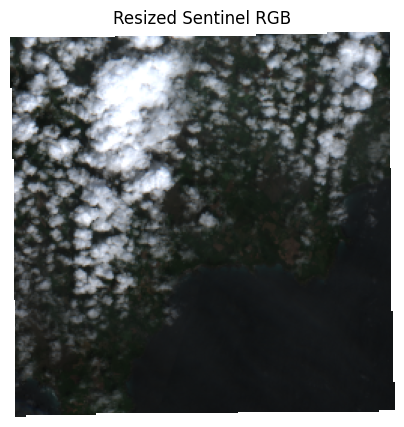

In [1]:
import matplotlib.pyplot as plt
import numpy as np

img_resized = np.load("sample_001.npy")

# RGB = B4, B3, B2
rgb = img_resized[:, :, [2, 1, 0]]

plt.figure(figsize=(5,5))
plt.imshow(np.clip(rgb, 0, 1))
plt.axis("off")
plt.title("Resized Sentinel RGB")
plt.show()
